# 03 Sentiment Analysis

Goal: create a transparent sentiment baseline for the cleaned S&P 500 headline dataset, aggregate headline-level sentiment into daily features, and save a modeling-ready table for later notebooks.

This notebook uses a lightweight dictionary method so the project remains reproducible with the current repository dependencies. A later version can replace or extend this baseline with VADER, FinBERT, or the Loughran-McDonald finance dictionary.

In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

HEADLINES_PATH = PROCESSED_DIR / "headlines_clean.csv"
DAILY_MACRO_PATH = PROCESSED_DIR / "daily_with_macro.csv"
HEADLINE_SENTIMENT_PATH = PROCESSED_DIR / "headlines_with_sentiment.csv"
DAILY_SENTIMENT_PATH = PROCESSED_DIR / "daily_with_sentiment.csv"

## Load Clean Inputs

In [2]:
headlines = pd.read_csv(HEADLINES_PATH, parse_dates=["Date"])
daily = pd.read_csv(DAILY_MACRO_PATH, parse_dates=["Date"])

print("Clean headline rows:", headlines.shape)
print("Daily rows with macro context:", daily.shape)
headlines.head()

Clean headline rows: (18153, 3)
Daily rows with macro context: (3506, 21)


,Title,Date,CP
0,2008 predictions for the S&P 500,2008-01-02,1447.16
1,Dow Tallies Biggest First-session-of-year Poin...,2008-01-02,1447.16
2,"JPMorgan Predicts 2008 Will Be ""Nothing But Net""",2008-01-02,1447.16
3,"U.S. Stocks Higher After Economic Data, Monsan...",2008-01-03,1447.16
4,U.S. Stocks Climb As Hopes Increase For More F...,2008-01-07,1416.18


## Dictionary Scoring Method

The baseline scores each headline with two related dictionaries:

- `general_sentiment_score`: broad positive and negative words.
- `finance_sentiment_score`: market-specific words and phrases such as rally, bear market, downgrade, rate hike, and recession.

Scores are normalized by headline length. Positive values indicate more positive words than negative words; negative values indicate the reverse.

In [3]:
TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)?|\d+(?:\.\d+)?%?")

NEGATORS = {"no", "not", "never", "without", "less", "lack", "lacks", "failed", "fails", "failure"}

GENERAL_POSITIVE = {
    "best", "better", "boost", "bright", "confidence", "confident", "easy", "gain", "gains",
    "good", "great", "growth", "higher", "hope", "hopes", "improve", "improved", "improves",
    "optimism", "optimistic", "positive", "relief", "rise", "rises", "strong", "stronger",
    "success", "successful", "support", "up", "win", "winning",
}

GENERAL_NEGATIVE = {
    "bad", "crisis", "decline", "declines", "drop", "drops", "fall", "falls", "fear", "fears",
    "fail", "failed", "fails", "loss", "losses", "negative", "panic", "plunge", "plunges",
    "poor", "pressure", "recession", "risk", "risks", "slump", "slumps", "tumble", "tumbles",
    "uncertain", "uncertainty", "weak", "weaker", "worst",
}

FINANCE_POSITIVE = {
    "advance", "advances", "beat", "beats", "bull", "bullish", "bulls", "buy", "climb",
    "climbs", "easing", "expansion", "gain", "gains", "growth", "higher", "outperform",
    "rallies", "rally", "rebound", "rebounds", "recover", "recovered", "recovery", "record",
    "resilient", "rise", "rises", "strong", "surge", "surges", "upgrade", "upgrades",
}

FINANCE_NEGATIVE = {
    "bear", "bearish", "bears", "crash", "crashes", "crisis", "debt", "default", "decline",
    "declines", "downgrade", "downgrades", "drop", "drops", "fall", "falls", "fear", "fears",
    "fell", "hike", "hikes", "inflation", "loss", "losses", "miss", "misses", "panic",
    "plunge", "plunges", "recession", "risk", "risks", "sell", "selling", "selloff", "slump",
    "slumps", "tightening", "tumble", "tumbles", "volatile", "volatility", "weak",
}

FINANCE_POSITIVE_PHRASES = {
    "all-time high", "bull market", "beats estimates", "fed cut", "rate cut", "record high",
    "soft landing", "stocks rally", "stocks rise",
}

FINANCE_NEGATIVE_PHRASES = {
    "banking crisis", "bear market", "circuit breaker", "credit crunch", "debt ceiling",
    "fed hike", "hard landing", "limit down", "rate hike", "sell off", "sell-off",
}


def tokenize(text: str) -> list[str]:
    return TOKEN_RE.findall(str(text).lower())


def count_phrase_hits(text: str, phrases: set[str]) -> int:
    text_lower = str(text).lower()
    return sum(phrase in text_lower for phrase in phrases)


def score_tokens(tokens: list[str], positive_words: set[str], negative_words: set[str]) -> tuple[int, int]:
    positive = 0
    negative = 0
    for i, token in enumerate(tokens):
        is_negated = any(prev in NEGATORS for prev in tokens[max(0, i - 3):i])
        if token in positive_words:
            negative += int(is_negated)
            positive += int(not is_negated)
        elif token in negative_words:
            positive += int(is_negated)
            negative += int(not is_negated)
    return positive, negative


def score_headline(text: str) -> pd.Series:
    tokens = tokenize(text)
    token_count = len(tokens)
    denominator = max(token_count, 1)

    general_positive, general_negative = score_tokens(tokens, GENERAL_POSITIVE, GENERAL_NEGATIVE)
    finance_positive, finance_negative = score_tokens(tokens, FINANCE_POSITIVE, FINANCE_NEGATIVE)
    finance_positive += count_phrase_hits(text, FINANCE_POSITIVE_PHRASES)
    finance_negative += count_phrase_hits(text, FINANCE_NEGATIVE_PHRASES)

    finance_score = (finance_positive - finance_negative) / denominator
    if finance_score > 0:
        label = "positive"
    elif finance_score < 0:
        label = "negative"
    else:
        label = "neutral"

    return pd.Series(
        {
            "token_count": token_count,
            "general_positive_count": general_positive,
            "general_negative_count": general_negative,
            "finance_positive_count": finance_positive,
            "finance_negative_count": finance_negative,
            "general_sentiment_score": (general_positive - general_negative) / denominator,
            "finance_sentiment_score": finance_score,
            "finance_sentiment_label": label,
        }
    )

## Score Headlines

In [4]:
score_columns = headlines["Title"].apply(score_headline)
headlines_scored = pd.concat([headlines, score_columns], axis=1)
headlines_scored.to_csv(HEADLINE_SENTIMENT_PATH, index=False)

print("Saved:", HEADLINE_SENTIMENT_PATH)
headlines_scored.head(10)

Saved: /Users/liuhaoyang/Desktop/sp500-main/data/processed/headlines_with_sentiment.csv


,Title,Date,CP,token_count,general_positive_count,general_negative_count,finance_positive_count,finance_negative_count,general_sentiment_score,finance_sentiment_score,finance_sentiment_label
0,2008 predictions for the S&P 500,2008-01-02,1447.16,7,0,0,0,0,0.000000,0.000000,neutral
1,Dow Tallies Biggest First-session-of-year Poin...,2008-01-02,1447.16,10,0,1,0,1,-0.100000,-0.100000,negative
2,"JPMorgan Predicts 2008 Will Be ""Nothing But Net""",2008-01-02,1447.16,8,0,0,0,0,0.000000,0.000000,neutral
3,"U.S. Stocks Higher After Economic Data, Monsan...",2008-01-03,1447.16,9,1,0,1,0,0.111111,0.111111,positive
4,U.S. Stocks Climb As Hopes Increase For More F...,2008-01-07,1416.18,11,1,0,1,0,0.090909,0.090909,positive
5,Head And Shoulders Top Bodes Ill For Bulls,2008-01-09,1409.13,8,0,0,1,0,0.000000,0.125000,positive
6,How Investing in Intangibles -- Like Employee ...,2008-01-09,1409.13,11,0,0,0,0,0.000000,0.000000,neutral
7,U.S. Stocks Zigzag Higher As Bernanke Speech S...,2008-01-10,1420.33,10,1,0,1,0,0.100000,0.100000,positive
8,It's a Black Monday as stock markets tank in e...,2008-01-22,1310.50,14,0,0,0,0,0.000000,0.000000,neutral
9,Marriage - Tracy Collier and John Helvey | Com...,2008-01-22,1310.50,7,0,0,0,0,0.000000,0.000000,neutral


In [5]:
label_summary = (
    headlines_scored["finance_sentiment_label"]
    .value_counts()
    .rename_axis("finance_sentiment_label")
    .reset_index(name="headline_count")
)
label_summary["share"] = label_summary["headline_count"] / len(headlines_scored)
label_summary

,finance_sentiment_label,headline_count,share
0,neutral,12399,0.683028
1,positive,3293,0.181403
2,negative,2461,0.135570


In [6]:
examples = pd.concat(
    [
        headlines_scored.nsmallest(8, "finance_sentiment_score"),
        headlines_scored.nlargest(8, "finance_sentiment_score"),
    ]
).sort_values("finance_sentiment_score")

examples[["Date", "Title", "finance_sentiment_score", "finance_sentiment_label"]]

,Date,Title,finance_sentiment_score,finance_sentiment_label
11295,2022-06-14,"Inflation, inflation, and more inflation",-0.600000,negative
678,2011-07-13,The Beer Bear Market,-0.500000,negative
5538,2017-10-11,Volker's Bear: The Bear Market Of 1982,-0.428571,negative
11265,2022-06-13,S&P 500 Falls Into Bear Market,-0.428571,negative
11324,2022-06-16,Wall Street plunges as recession fears grow,-0.428571,negative
14140,2023-05-19,Markets Fall as Debt Ceiling Talks Pause,-0.428571,negative
14515,2023-06-16,Bear Markets: How Deep Is Your Loss?,-0.428571,negative
7035,2019-08-05,NOW It's A Bear Market,-0.400000,negative
524,2011-03-11,Stocks rise after Japan earthquake,0.400000,positive
1611,2012-11-01,Buy November's Historical Bull Cycle?,0.400000,positive


## Aggregate to Daily Features

The modeling notebooks should use daily-level features because the target is next trading day's S&P 500 return.

In [7]:
daily_sentiment = (
    headlines_scored.groupby("Date")
    .agg(
        scored_headline_count=("Title", "size"),
        total_token_count=("token_count", "sum"),
        avg_general_sentiment=("general_sentiment_score", "mean"),
        avg_finance_sentiment=("finance_sentiment_score", "mean"),
        finance_sentiment_std=("finance_sentiment_score", "std"),
        max_finance_sentiment=("finance_sentiment_score", "max"),
        min_finance_sentiment=("finance_sentiment_score", "min"),
        positive_headline_share=("finance_sentiment_label", lambda values: (values == "positive").mean()),
        negative_headline_share=("finance_sentiment_label", lambda values: (values == "negative").mean()),
        neutral_headline_share=("finance_sentiment_label", lambda values: (values == "neutral").mean()),
    )
    .reset_index()
)

daily_sentiment["finance_sentiment_std"] = daily_sentiment["finance_sentiment_std"].fillna(0)
daily_sentiment["net_positive_negative_share"] = (
    daily_sentiment["positive_headline_share"] - daily_sentiment["negative_headline_share"]
)

daily_with_sentiment = daily.merge(daily_sentiment, on="Date", how="left")

sentiment_feature_cols = [
    "scored_headline_count",
    "total_token_count",
    "avg_general_sentiment",
    "avg_finance_sentiment",
    "finance_sentiment_std",
    "max_finance_sentiment",
    "min_finance_sentiment",
    "positive_headline_share",
    "negative_headline_share",
    "neutral_headline_share",
    "net_positive_negative_share",
]
daily_with_sentiment[sentiment_feature_cols] = daily_with_sentiment[sentiment_feature_cols].fillna(0)
daily_with_sentiment.to_csv(DAILY_SENTIMENT_PATH, index=False)

print("Saved:", DAILY_SENTIMENT_PATH)
daily_with_sentiment.head()

Saved: /Users/liuhaoyang/Desktop/sp500-main/data/processed/daily_with_sentiment.csv


,Date,CP,headline_count,unique_headline_count,daily_text,close_next_day,return_next_day,direction_next_day,return_same_day,year,...,total_token_count,avg_general_sentiment,avg_finance_sentiment,finance_sentiment_std,max_finance_sentiment,min_finance_sentiment,positive_headline_share,negative_headline_share,neutral_headline_share,net_positive_negative_share
0,2008-01-02,1447.16,3,3,2008 predictions for the S&P 500 . Dow Tallies...,1447.16,0.000000,0,NaN,2008,...,25,-0.033333,-0.033333,0.057735,0.000000,-0.100000,0.0,0.333333,0.666667,-0.333333
1,2008-01-03,1447.16,1,1,"U.S. Stocks Higher After Economic Data, Monsan...",1416.18,-0.021407,0,0.000000,2008,...,9,0.111111,0.111111,0.000000,0.111111,0.111111,1.0,0.000000,0.000000,1.000000
2,2008-01-07,1416.18,1,1,U.S. Stocks Climb As Hopes Increase For More F...,1409.13,-0.004978,0,-0.021407,2008,...,11,0.090909,0.090909,0.000000,0.090909,0.090909,1.0,0.000000,0.000000,1.000000
3,2008-01-09,1409.13,2,2,Head And Shoulders Top Bodes Ill For Bulls . H...,1420.33,0.007948,1,-0.004978,2008,...,19,0.000000,0.062500,0.088388,0.125000,0.000000,0.5,0.000000,0.500000,0.500000
4,2008-01-10,1420.33,1,1,U.S. Stocks Zigzag Higher As Bernanke Speech S...,1310.50,-0.077327,0,0.007948,2008,...,10,0.100000,0.100000,0.000000,0.100000,0.100000,1.0,0.000000,0.000000,1.000000


## Relationship with Next-Day Returns

These are descriptive checks, not a final predictive model. The next notebook should use time-aware validation before making model claims.

In [8]:
correlation_features = [
    "avg_general_sentiment",
    "avg_finance_sentiment",
    "positive_headline_share",
    "negative_headline_share",
    "net_positive_negative_share",
    "finance_sentiment_std",
    "headline_count",
]

correlation_summary = (
    daily_with_sentiment[correlation_features + ["return_next_day", "direction_next_day"]]
    .corr(numeric_only=True)
    .loc[correlation_features, ["return_next_day", "direction_next_day"]]
    .reset_index()
    .rename(
        columns={
            "index": "feature",
            "return_next_day": "corr_with_next_day_return",
            "direction_next_day": "corr_with_next_day_direction",
        }
    )
)

correlation_summary.to_csv(PROCESSED_DIR / "sentiment_correlation_summary.csv", index=False)
correlation_summary

,feature,corr_with_next_day_return,corr_with_next_day_direction
0,avg_general_sentiment,-0.007692,0.007357
1,avg_finance_sentiment,-0.011970,0.022013
2,positive_headline_share,-0.006704,0.000267
3,negative_headline_share,0.000393,-0.032419
4,net_positive_negative_share,-0.004953,0.020930
5,finance_sentiment_std,0.014341,-0.021964
6,headline_count,0.021575,-0.009415


In [9]:
daily_with_sentiment["finance_sentiment_tercile"] = pd.qcut(
    daily_with_sentiment["avg_finance_sentiment"].rank(method="first"),
    q=3,
    labels=["low", "middle", "high"],
)

tercile_summary = (
    daily_with_sentiment.groupby("finance_sentiment_tercile", observed=True)
    .agg(
        days=("Date", "count"),
        avg_finance_sentiment=("avg_finance_sentiment", "mean"),
        avg_next_return=("return_next_day", "mean"),
        median_next_return=("return_next_day", "median"),
        up_day_rate=("direction_next_day", "mean"),
        avg_vix=("vix", "mean"),
    )
    .reset_index()
)

tercile_summary.to_csv(PROCESSED_DIR / "sentiment_tercile_summary.csv", index=False)
tercile_summary

,finance_sentiment_tercile,days,avg_finance_sentiment,avg_next_return,median_next_return,up_day_rate,avg_vix
0,low,1169,-0.030096,0.000331,0.000594,0.526091,22.929624
1,middle,1168,0.000000,0.000536,0.000880,0.561644,16.944983
2,high,1169,0.040466,0.000490,0.000597,0.541488,17.930958


In [10]:
sentiment_regime_summary = (
    daily_with_sentiment.groupby("regime")
    .agg(
        days=("Date", "count"),
        avg_finance_sentiment=("avg_finance_sentiment", "mean"),
        positive_headline_share=("positive_headline_share", "mean"),
        negative_headline_share=("negative_headline_share", "mean"),
        avg_next_return=("return_next_day", "mean"),
        volatility=("return_next_day", "std"),
        up_day_rate=("direction_next_day", "mean"),
        avg_vix=("vix", "mean"),
    )
    .reset_index()
)

sentiment_regime_summary.to_csv(PROCESSED_DIR / "sentiment_regime_summary.csv", index=False)
sentiment_regime_summary

,regime,days,avg_finance_sentiment,positive_headline_share,negative_headline_share,avg_next_return,volatility,up_day_rate,avg_vix
0,2008-2009 financial crisis,196,-0.008198,0.119048,0.170918,-0.000704,0.032475,0.540816,33.010918
1,2020 COVID shock,249,0.007198,0.175092,0.119160,0.000752,0.021846,0.566265,29.234538
2,2022-2023 rate-hike cycle,495,-0.002954,0.194562,0.197133,0.000053,0.012290,0.486869,21.303111
3,Other,2566,0.005222,0.124347,0.084560,0.000589,0.009665,0.551832,16.860164


In [11]:
sentiment_summary = {
    "headline_rows_scored": int(len(headlines_scored)),
    "daily_rows_with_sentiment": int(len(daily_with_sentiment)),
    "headline_label_counts": {
        row["finance_sentiment_label"]: int(row["headline_count"])
        for _, row in label_summary.iterrows()
    },
    "mean_daily_finance_sentiment": float(daily_with_sentiment["avg_finance_sentiment"].mean()),
    "mean_daily_general_sentiment": float(daily_with_sentiment["avg_general_sentiment"].mean()),
    "corr_avg_finance_sentiment_next_return": float(
        correlation_summary.loc[
            correlation_summary["feature"] == "avg_finance_sentiment",
            "corr_with_next_day_return",
        ].iloc[0]
    ),
}

(PROCESSED_DIR / "sentiment_summary.json").write_text(
    json.dumps(sentiment_summary, indent=2), encoding="utf-8"
)
sentiment_summary

{'headline_rows_scored': 18153,
 'daily_rows_with_sentiment': 3506,
 'headline_label_counts': {'neutral': 12399,
  'positive': 3293,
  'negative': 2461},
 'mean_daily_finance_sentiment': 0.0034576717817079872,
 'mean_daily_general_sentiment': 0.005201588849159752,
 'corr_avg_finance_sentiment_next_return': -0.011969518253028288}

## Visual Checks

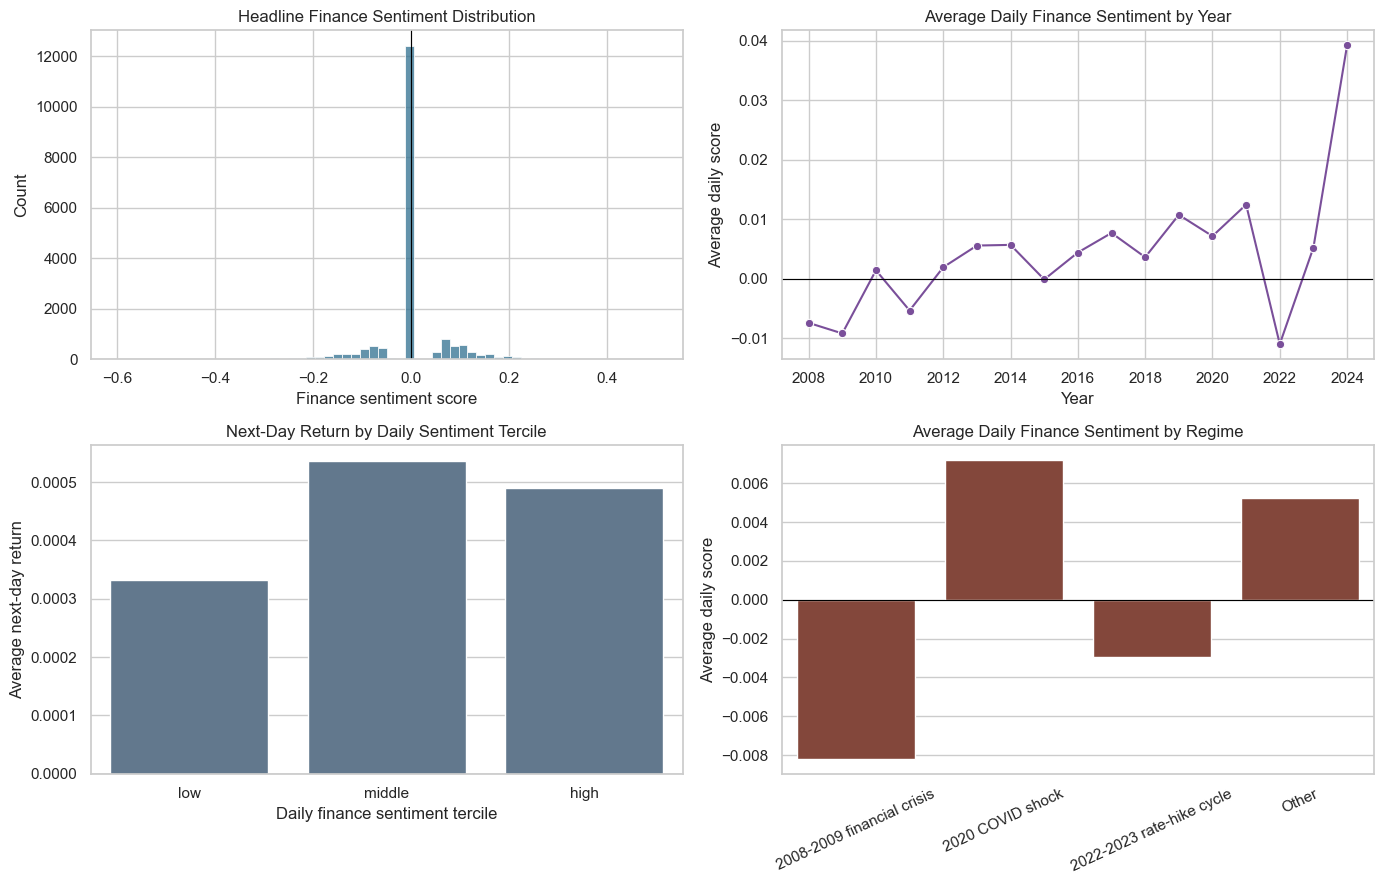

In [12]:
yearly_sentiment = (
    daily_with_sentiment.groupby("year")
    .agg(
        avg_finance_sentiment=("avg_finance_sentiment", "mean"),
        positive_headline_share=("positive_headline_share", "mean"),
        negative_headline_share=("negative_headline_share", "mean"),
        avg_headline_count=("headline_count", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.histplot(headlines_scored["finance_sentiment_score"], bins=60, ax=axes[0, 0], color="#2f6f8f")
axes[0, 0].axvline(0, color="black", linewidth=0.8)
axes[0, 0].set_title("Headline Finance Sentiment Distribution")
axes[0, 0].set_xlabel("Finance sentiment score")

sns.lineplot(
    data=yearly_sentiment,
    x="year",
    y="avg_finance_sentiment",
    marker="o",
    ax=axes[0, 1],
    color="#7a4f9a",
)
axes[0, 1].axhline(0, color="black", linewidth=0.8)
axes[0, 1].set_title("Average Daily Finance Sentiment by Year")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Average daily score")

sns.barplot(
    data=tercile_summary,
    x="finance_sentiment_tercile",
    y="avg_next_return",
    ax=axes[1, 0],
    color="#5b7894",
)
axes[1, 0].axhline(0, color="black", linewidth=0.8)
axes[1, 0].set_title("Next-Day Return by Daily Sentiment Tercile")
axes[1, 0].set_xlabel("Daily finance sentiment tercile")
axes[1, 0].set_ylabel("Average next-day return")

sns.barplot(
    data=sentiment_regime_summary,
    x="regime",
    y="avg_finance_sentiment",
    ax=axes[1, 1],
    color="#8f3f2f",
)
axes[1, 1].axhline(0, color="black", linewidth=0.8)
axes[1, 1].set_title("Average Daily Finance Sentiment by Regime")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Average daily score")
axes[1, 1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "sentiment_analysis_summary.png", dpi=200)
plt.show()

## Modeling Handoff

Main output for the next stage:

- `data/processed/headlines_with_sentiment.csv`: headline-level sentiment scores.
- `data/processed/daily_with_sentiment.csv`: daily market, macro, target, and sentiment features.
- `data/processed/sentiment_correlation_summary.csv`: descriptive correlations with next-day outcomes.
- `data/processed/sentiment_tercile_summary.csv`: next-day outcomes grouped by daily sentiment tercile.
- `data/processed/sentiment_regime_summary.csv`: sentiment and return summary by market regime.
- `figures/sentiment_analysis_summary.png`: visual summary for report or slides.

Caution: dictionary sentiment is a baseline. It is transparent and reproducible, but it can misread context, irony, company-specific nuance, and phrases where the same word has different meanings in macro and equity-market settings.